TUGAS BESAR DATA MINING
**"ANALISIS PENGARUH USIA KENDARAAN, JARAK TEMPUH, DAN JENIS BAHAN BAKAR TERHADAP HARGA JUAL MOBIL BEKAS MENGGUNAKAN REGRESI LINIER"**


BAB 3

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

In [ ]:
df = pd.read_csv('car details v4.csv')

In [ ]:
df = df.drop_duplicates()
print(f"Sisa baris data sekarang: {df.shape[0]}")

Sisa baris data sekarang: 2059


In [ ]:
df['Engine'] = df['Engine'].astype(str).str.replace(' cc', '').astype(float)
df['Max Power'] = df['Max Power'].astype(str).str.extract(r'([\d.]+)').astype(float)

In [ ]:
for col in ['Price', 'Kilometer', 'Engine', 'Max Power']:
    df[col] = df[col].fillna(df[col].median())
for col in ['Fuel Type', 'Seller Type', 'Transmission', 'Owner']:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

,0
Make,0
Model,0
Price,0
Year,0
Kilometer,0
Fuel Type,0
Transmission,0
Location,0
Color,0
Owner,0


In [ ]:
df['Umur_Kendaraan'] = 2026 - df['Year']
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,...,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Umur_Kendaraan
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,...,1198.0,87.0,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0,9
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,...,1248.0,74.0,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0,12
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,...,1197.0,79.0,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0,15
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,...,1197.0,82.0,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0,7
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,...,2393.0,148.0,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0,8


In [ ]:
for col in ['Price', 'Kilometer']:
    q_low = df[col].quantile(0.01)
    q_hi  = df[col].quantile(0.99)
    df[col] = np.where(df[col] < q_low, q_low, df[col])
    df[col] = np.where(df[col] > q_hi, q_hi, df[col])

In [ ]:
kolom_relevan = [
'Price',
'Umur_Kendaraan',
'Kilometer',
'Fuel Type',
'Seller Type',
'Transmission',
'Owner',
'Engine',
'Max Power'
]
df_model = df[kolom_relevan]

In [ ]:
df_encoded = pd.get_dummies(df_model, columns=['Fuel Type', 'Seller Type', 'Transmission', 'Owner'], drop_first=True)

In [ ]:
X = df_encoded.drop('Price', axis=1)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [ ]:
kmeans = KMeans(n_clusters=3, n_init=20, max_iter=300, random_state=42)
df_encoded['Cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
print("Jumlah data per kluster:")
print(df_encoded['Cluster'].value_counts())

Jumlah data per kluster:
Cluster
0    1058
1     944
2      57
Name: count, dtype: int64


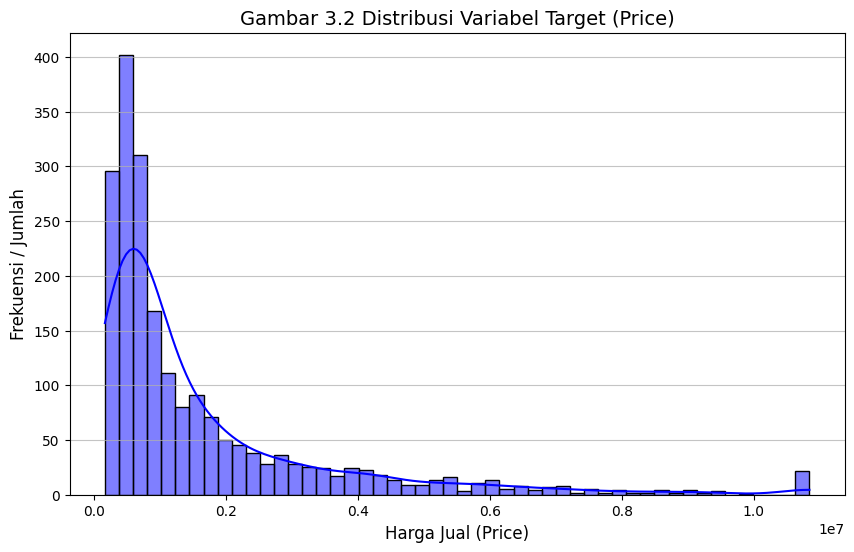

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, color='blue', bins=50)
plt.title('Gambar 3.2 Distribusi Variabel Target (Price)', fontsize=14)
plt.xlabel('Harga Jual (Price)', fontsize=12)
plt.ylabel('Frekuensi / Jumlah', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

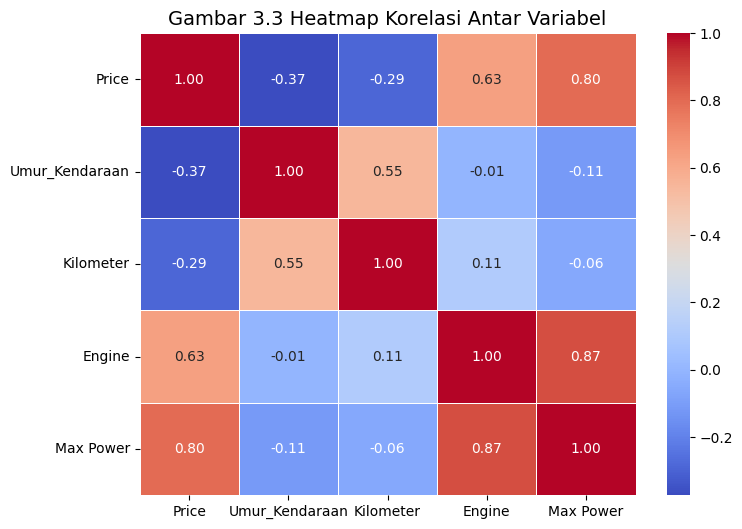

In [ ]:
kolom_numerik = ['Price', 'Umur_Kendaraan', 'Kilometer', 'Engine', 'Max Power']
matriks_korelasi = df[kolom_numerik].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriks_korelasi, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Gambar 3.3 Heatmap Korelasi Antar Variabel', fontsize=14)
plt.show()

BAB 4

In [ ]:
df_clean = df.drop_duplicates().copy()
df_clean['Engine'] = df_clean['Engine'].astype(str).str.extract(r'(\d+)').astype(float)
df_clean['Max Power'] = df_clean['Max Power'].astype(str).str.extract(r'([\d.]+)').astype(float)

In [ ]:
kolom_tabel = ['Price', 'Kilometer', 'Year', 'Engine', 'Max Power']
stats = df_clean[kolom_tabel].describe().T[['min', 'max', 'mean', 'std']]
stats.columns = ['Minimum', 'Maksimum', 'Rata-rata', 'Std. Deviasi']

print("--- Tabel 4.1: Deskripsi Statistik Dataset ---")
display(stats.round(2))

--- Tabel 4.1: Deskripsi Statistik Dataset ---


,Minimum,Maksimum,Rata-rata,Std. Deviasi
Price,160000.00,10842000.0,1633281.16,1932952.04
Kilometer,2404.24,147100.0,52484.58,30576.93
Year,1988.00,2022.0,2016.43,3.36
Engine,624.00,6592.0,1685.02,632.22
Max Power,35.00,660.0,129.08,63.85


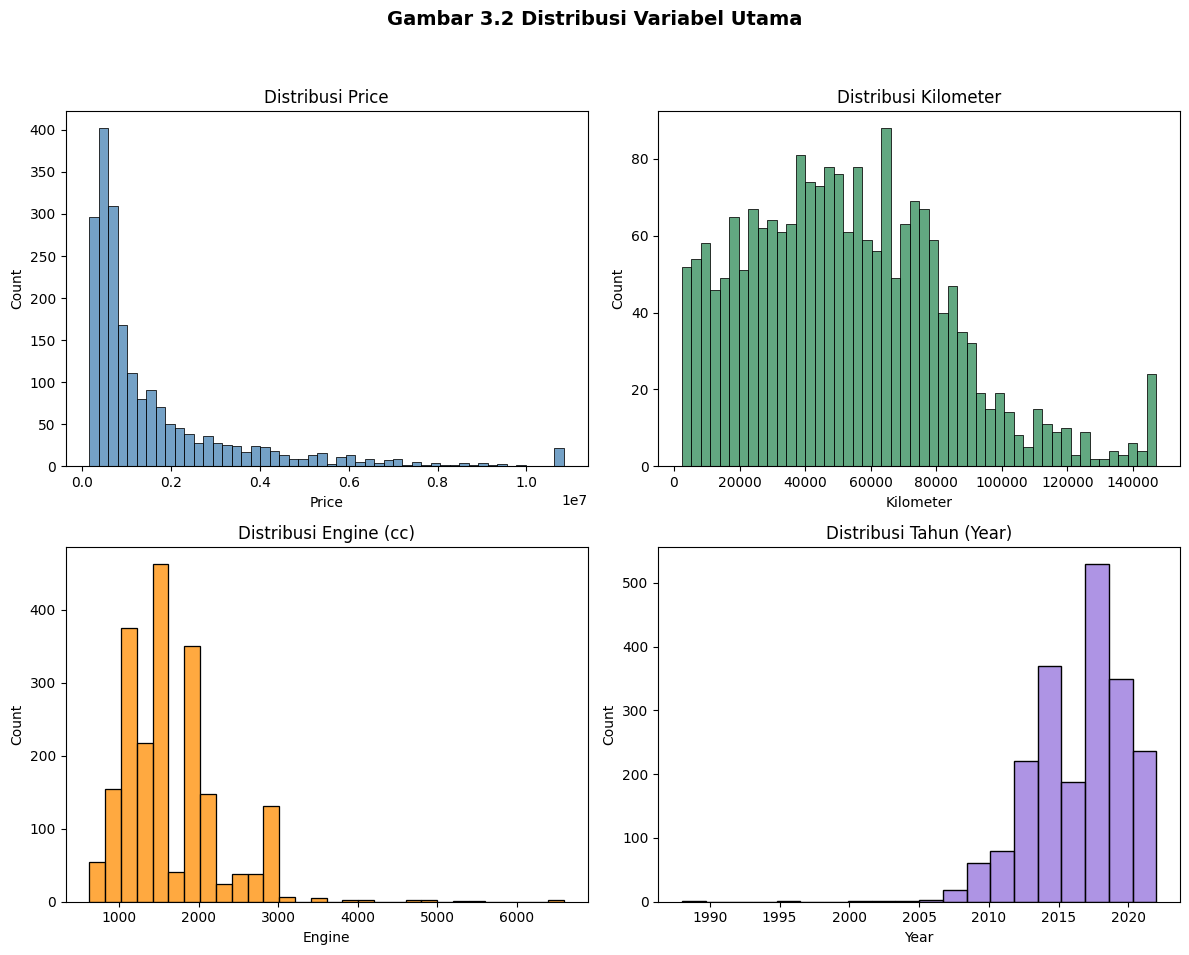

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Gambar 3.2 Distribusi Variabel Utama', fontsize=14, fontweight='bold')

sns.histplot(df_clean['Price'], ax=axes[0,0], color='steelblue', bins=50)
axes[0,0].set_title('Distribusi Price')

sns.histplot(df_clean['Kilometer'], ax=axes[0,1], color='seagreen', bins=50)
axes[0,1].set_title('Distribusi Kilometer')

sns.histplot(df_clean['Engine'], ax=axes[1,0], color='darkorange', bins=30)
axes[1,0].set_title('Distribusi Engine (cc)')

sns.histplot(df_clean['Year'], ax=axes[1,1], color='mediumpurple', bins=20)
axes[1,1].set_title('Distribusi Tahun (Year)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

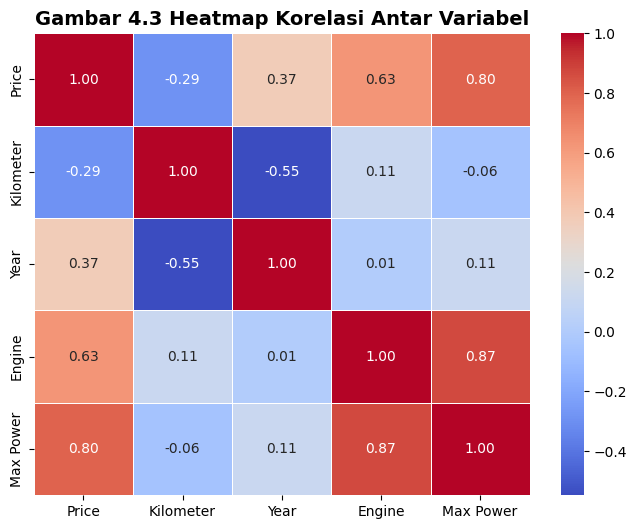

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[kolom_tabel].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Gambar 4.3 Heatmap Korelasi Antar Variabel', fontsize=14, fontweight='bold')
plt.show()

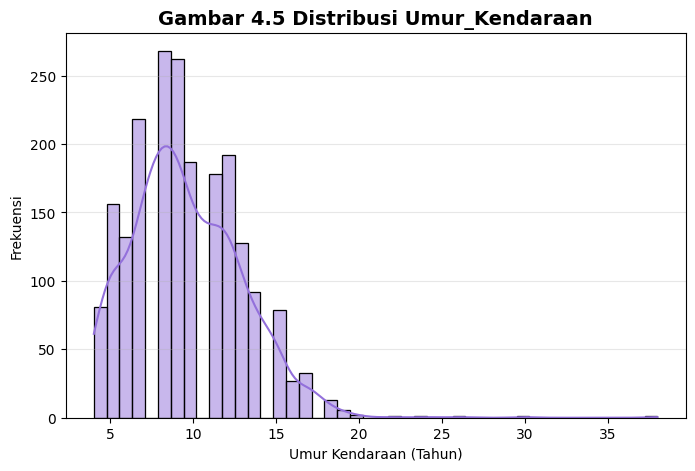

In [ ]:
if 'Umur_Kendaraan' not in df.columns:
    df['Umur_Kendaraan'] = 2026 - df['Year']

plt.figure(figsize=(8, 5))
sns.histplot(df['Umur_Kendaraan'], kde=True, color='mediumpurple')

plt.title('Gambar 4.5 Distribusi Umur_Kendaraan', fontsize=14, fontweight='bold')
plt.xlabel('Umur Kendaraan (Tahun)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
print("--- Tabel 4.3 (Bagian 1): Contoh Data Sebelum Encoding ---")
display(df_clean[['Fuel Type', 'Transmission', 'Seller Type', 'Owner']].head())
df_encoded = pd.get_dummies(df_clean, columns=['Fuel Type', 'Transmission', 'Seller Type', 'Owner'])
print("\n--- Tabel 4.3 (Bagian 2): Contoh Data SESUDAH Encoding ---")
display(df_encoded.head())

--- Tabel 4.3 (Bagian 1): Contoh Data SEBELUM Encoding ---


,Fuel Type,Transmission,Seller Type,Owner
0,Petrol,Manual,Corporate,First
1,Diesel,Manual,Individual,Second
2,Petrol,Manual,Individual,First
3,Petrol,Manual,Individual,First
4,Diesel,Manual,Individual,First



--- Tabel 4.3 (Bagian 2): Contoh Data SESUDAH Encoding ---


,Make,Model,Price,Year,Kilometer,Location,Color,Engine,Max Power,Max Torque,...,Transmission_Manual,Seller Type_Commercial Registration,Seller Type_Corporate,Seller Type_Individual,Owner_4 or More,Owner_First,Owner_Fourth,Owner_Second,Owner_Third,Owner_UnRegistered Car
0,Honda,Amaze 1.2 VX i-VTEC,505000.0,2017,87150.0,Pune,Grey,1198.0,87.0,109 Nm @ 4500 rpm,...,True,False,True,False,False,True,False,False,False,False
1,Maruti Suzuki,Swift DZire VDI,450000.0,2014,75000.0,Ludhiana,White,1248.0,74.0,190 Nm @ 2000 rpm,...,True,False,False,True,False,False,False,True,False,False
2,Hyundai,i10 Magna 1.2 Kappa2,220000.0,2011,67000.0,Lucknow,Maroon,1197.0,79.0,112.7619 Nm @ 4000 rpm,...,True,False,False,True,False,True,False,False,False,False
3,Toyota,Glanza G,799000.0,2019,37500.0,Mangalore,Red,1197.0,82.0,113 Nm @ 4200 rpm,...,True,False,False,True,False,True,False,False,False,False
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000.0,2018,69000.0,Mumbai,Grey,2393.0,148.0,343 Nm @ 1400 rpm,...,True,False,False,True,False,True,False,False,False,False


In [ ]:
data_for_clustering = data_for_clustering.fillna(data_for_clustering.median())

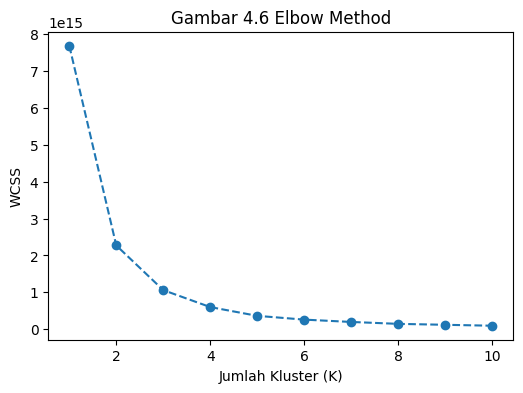

In [ ]:
wcss = []
K_range = range(1, 11)
for i in K_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(data_for_clustering) # Sekarang seharusnya sudah lancar!
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Gambar 4.6 Elbow Method')
plt.xlabel('Jumlah Kluster (K)')
plt.ylabel('WCSS')
plt.show()

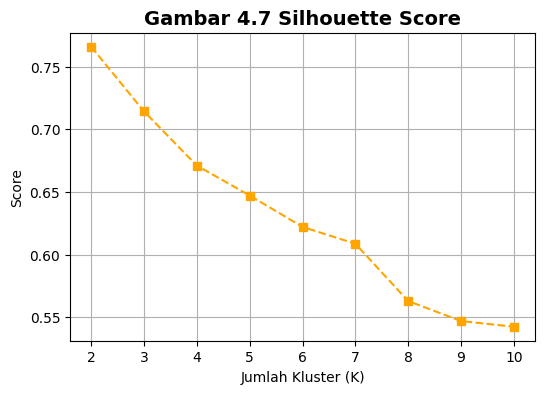

In [ ]:
sil_scores = []
K_range = range(2, 11)

for i in K_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(data_for_clustering)
    score = silhouette_score(data_for_clustering, labels)
    sil_scores.append(score)

plt.figure(figsize=(6, 4))
plt.plot(K_range, sil_scores, marker='s', color='orange', linestyle='--')
plt.title('Gambar 4.7 Silhouette Score', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Kluster (K)')
plt.ylabel('Score')
plt.grid(True)
plt.show()

In [ ]:
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42)
df_clean['Cluster'] = kmeans_final.fit_predict(data_for_clustering)

cluster_profile = df_clean.groupby('Cluster')[['Umur_Kendaraan', 'Kilometer', 'Engine', 'Max Power', 'Price']].mean()

cluster_profile = cluster_profile.sort_values(by='Price')
cluster_profile['Label_Segmen'] = ['Ekonomis', 'Menengah', 'Premium']

print("--- Tabel 4.4 Profil Rata-rata Setiap Kluster ---")
display(cluster_profile.round(2))

--- Tabel 4.4 Profil Rata-rata Setiap Kluster ---


,Umur_Kendaraan,Kilometer,Engine,Max Power,Price,Label_Segmen
Cluster,,,,,,
1,10.10,56148.21,1493.38,105.58,787100.00,Ekonomis
0,8.25,45263.21,2236.66,190.68,3446441.34,Menengah
2,6.41,23589.43,2640.51,265.69,7842839.28,Premium


In [ ]:
if 'Cluster' not in df_clean.columns:
    print("Kolom 'Cluster' belum ditemukan, menjalankan K-Means...")
    kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42)
    df_clean['Cluster'] = kmeans_final.fit_predict(data_for_clustering)
else:
    print("Kolom 'Cluster' sudah ada, lanjut ke PCA.")

Kolom 'Cluster' sudah ada, lanjut ke PCA.


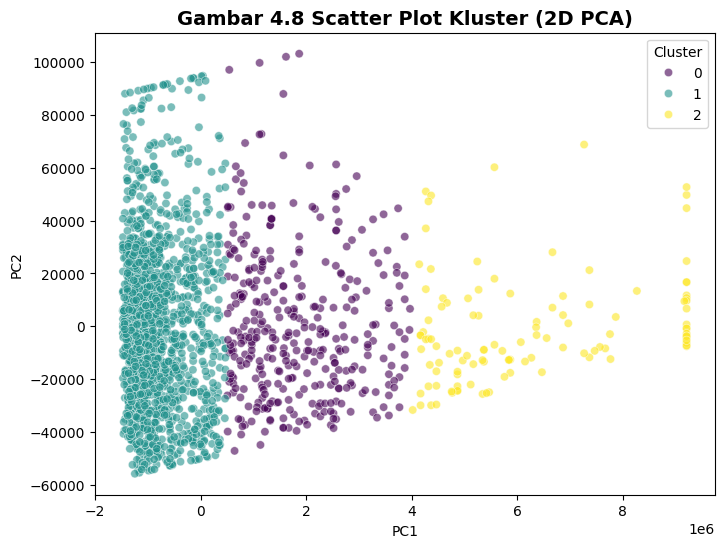

In [ ]:
pca = PCA(n_components=2)
components = pca.fit_transform(data_for_clustering)

df_pca = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df_clean['Cluster'].values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='viridis', alpha=0.6)
plt.title('Gambar 4.8 Scatter Plot Kluster (2D PCA)', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
results = []
cluster_names = {0: 'Ekonomis', 1: 'Menengah', 2: 'Premium'}

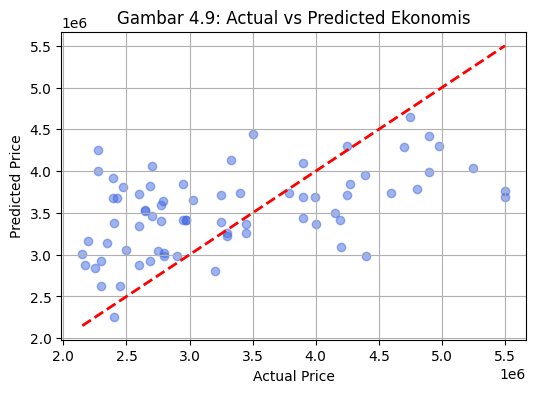

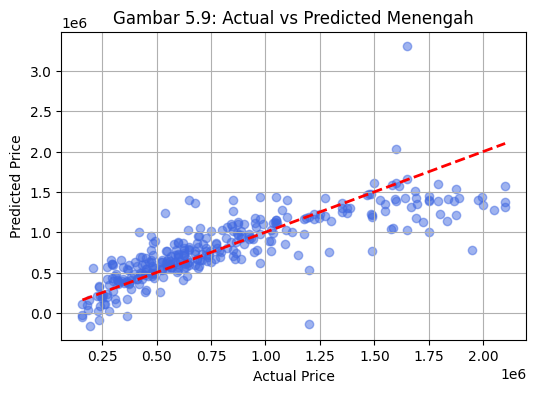

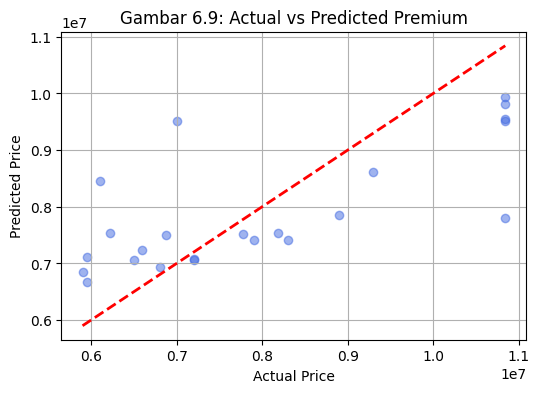

In [ ]:
for cluster_id in [0, 1, 2]:
    df_sub = df_clean[df_clean['Cluster'] == cluster_id]

    X = df_sub[['Umur_Kendaraan', 'Kilometer', 'Engine', 'Max Power']]
    y = df_sub['Price']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    results.append({'Segmen': cluster_names[cluster_id], 'R-Squared': round(r2, 4), 'MAE': round(mae, 2)})

    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, y_pred, alpha=0.5, color='royalblue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title(f'Gambar {4.9 + cluster_id}: Actual vs Predicted {cluster_names[cluster_id]}')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.grid(True)
    plt.show()

In [ ]:
print("--- Tabel 4.5 Ringkasan Metrik Evaluasi ---")
display(pd.DataFrame(results))

--- Tabel 4.5 Ringkasan Metrik Evaluasi ---


,Segmen,R-Squared,MAE
0,Ekonomis,0.1975,682633.37
1,Menengah,0.6565,185323.04
2,Premium,0.5100,993932.49


In [ ]:
df_clean['Cluster'].value_counts().sort_index()

,count
Cluster,
0,358
1,1589
2,112
